# Hedge Algebra trên final_data.csv
Triển khai hai tài liệu trong docs: HA-FCM (2010) và HABR-SIG/HABR-MUL (2019). Đánh giá classification_report và confusion_matrix như modeling.ipynb.

Đây là áp dụng thuật toán lên OULAD, không phải tái lập các bảng thực nghiệm Iris/KEEL. Chia 80/20 như notebook mẫu; 20% của phần train làm validation. Tối ưu trên validation, test chỉ đánh giá cuối cùng. Dữ liệu toàn khóa có average_score và has_unregistered: kết quả là phân loại cuối khóa, không phải dự báo sớm.

Nguồn đối chiếu công thức bị thiếu trong Markdown: [HA-FCM](https://doi.org/10.1145/1852611.1852621), [HABR](https://vjs.ac.vn/jcc/article/download/14348/383257/394092).

Điều chỉnh để chạy trên OULAD: thuộc tính danh nghĩa dùng điều kiện bằng nhau; IFRG sinh luật bằng beam search thay vì vét cạn mọi tổ hợp; ngân sách GA/MOPSO mặc định nhỏ hơn bài báo. Công thức trọng số khoảng, SQM, độ gần, confidence/support, CF và Single Winner Rule giữ theo tài liệu. Các điều chỉnh này không được xem là tái lập nguyên vẹn thực nghiệm bài báo.


In [1]:
from pathlib import Path
from itertools import combinations
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from scipy.spatial.distance import cdist

SEED = 42
# Ngân sách tính toán; bài 2019 dùng 600 particles, 250/1000 generations.
GA_POP, GA_GEN = 12, 8
PSO_POP, SEM_GEN, RULE_GEN = 10, 8, 12
MAX_ITER, TOL = 150, 1e-5
BEAM_PER_CLASS, RULES_PER_CLASS, MAX_RULE_LENGTH = 30, 300, 3
rng = np.random.default_rng(SEED)


In [2]:
DATA_PATH = Path('final_data.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError('Chạy notebook trong thư mục chứa final_data.csv.')
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
assert {'id_student', 'final_result'}.issubset(df.columns)
df = df.dropna(subset=['final_result']).reset_index(drop=True)
X = df.drop(columns=['id_student', 'final_result'])
encoder = LabelEncoder()
y = encoder.fit_transform(df['final_result'])
target_names = encoder.classes_.astype(str)
labels = np.arange(len(target_names))
train_idx, test_idx = train_test_split(np.arange(len(df)), test_size=0.2,
                                      random_state=SEED, stratify=y)
fit_idx, val_idx = train_test_split(train_idx, test_size=0.2,
                                    random_state=SEED, stratify=y[train_idx])
assert not set(train_idx) & set(test_idx)
assert not set(fit_idx) & set(val_idx)
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print('Dữ liệu:', df.shape, '| Train/validation/test:', len(fit_idx), len(val_idx), len(test_idx))
display(pd.Series(df['final_result'].value_counts(), name='Số mẫu'))

# Fit preprocessing riêng cho giai đoạn tuning và refit cuối cùng.
def make_preprocessor():
    return ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                          ('scale', MinMaxScaler(clip=True))]), num_cols),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                          ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
    ], sparse_threshold=0)

def prepare(train, other):
    prep = make_preprocessor()
    a = prep.fit_transform(X.iloc[train])
    b = prep.transform(X.iloc[other])
    assert np.isfinite(a).all() and np.isfinite(b).all()
    return prep, a, b

prep_tune, A_fit, A_val = prepare(fit_idx, val_idx)
prep_final, A_train, A_test = prepare(train_idx, test_idx)
results, predictions = [], {}

def evaluate(name, pred):
    predictions[name] = np.asarray(pred)
    print('\nModel:', name)
    print(classification_report(y[test_idx], pred, labels=labels,
                                target_names=target_names, zero_division=0))
    cm = confusion_matrix(y[test_idx], pred, labels=labels)
    assert cm.sum() == len(test_idx)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix: ' + name)
    plt.xlabel('Predicted Labels'); plt.ylabel('True Labels')
    plt.tight_layout(); plt.show()
    results.append({'Model': name, 'Accuracy': accuracy_score(y[test_idx], pred),
                    'Macro F1': f1_score(y[test_idx], pred, average='macro', zero_division=0),
                    'Weighted F1': f1_score(y[test_idx], pred, average='weighted', zero_division=0)})


Dữ liệu: (32593, 19) | Train/validation/test: 20859 5215 6519


final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: Số mẫu, dtype: int64

## 1. K-means, FCM và HA-FCM
HA-FCM dùng k=2, các khoảng theo thứ tự VF, MF, PF, LF, LT, PT, MT, VT. Với r=1-d/dmax, trọng số là độ dài khoảng chứa r. Khoảng cách mới là w_ij*d_ij; tâm chỉ dùng mẫu có u_ij > w (công thức 8). Nếu không có mẫu vượt ngưỡng, giữ tâm cũ. Bán kính dmax được lưu từ train và giữ cố định khi predict để kết quả không phụ thuộc batch test.

Ánh xạ cụm sang nhãn bằng lớp đa số trên train, không dùng nhãn test; nhiều cụm có thể cùng lớp. GA tối ưu w, bốn độ đo hedge và m theo accuracy validation.


GA 1/8: validation accuracy=0.5091


GA 2/8: validation accuracy=0.5091


GA 3/8: validation accuracy=0.5254


GA 4/8: validation accuracy=0.5254


GA 5/8: validation accuracy=0.5254


GA 6/8: validation accuracy=0.5254


GA 7/8: validation accuracy=0.5254


GA 8/8: validation accuracy=0.5254

Model: K-means
              precision    recall  f1-score   support

 Distinction       0.00      0.00      0.00       605
        Fail       0.00      0.00      0.00      1411
        Pass       0.38      1.00      0.55      2472
   Withdrawn       0.00      0.00      0.00      2031

    accuracy                           0.38      6519
   macro avg       0.09      0.25      0.14      6519
weighted avg       0.14      0.38      0.21      6519



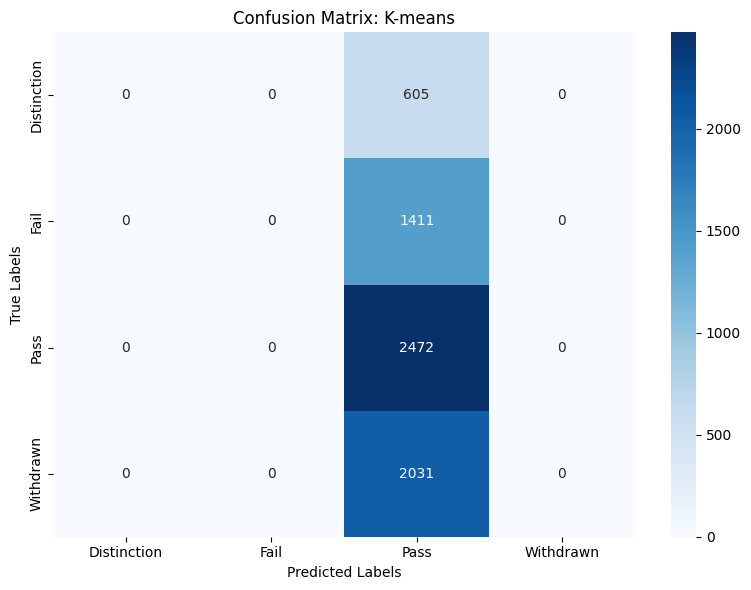


Model: FCM
              precision    recall  f1-score   support

 Distinction       0.00      0.00      0.00       605
        Fail       0.00      0.00      0.00      1411
        Pass       0.38      1.00      0.55      2472
   Withdrawn       1.00      0.00      0.00      2031

    accuracy                           0.38      6519
   macro avg       0.34      0.25      0.14      6519
weighted avg       0.46      0.38      0.21      6519



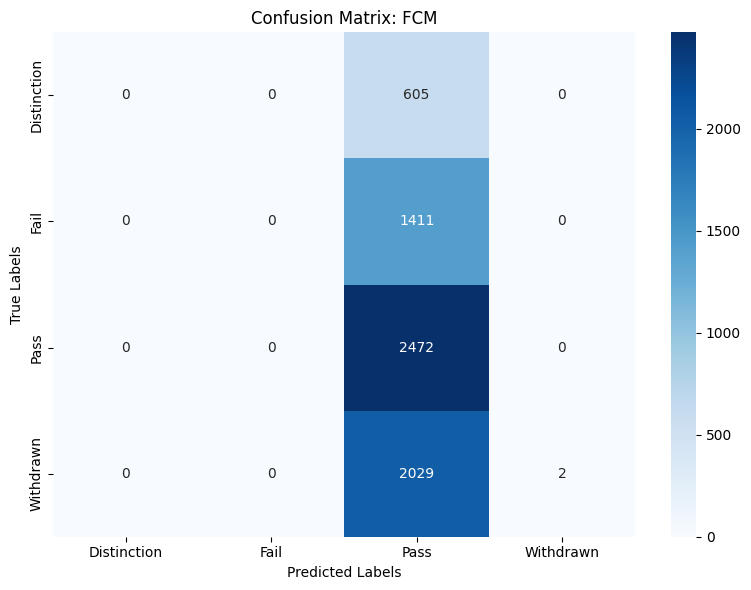


Model: HA-FCM
              precision    recall  f1-score   support

 Distinction       0.00      0.00      0.00       605
        Fail       0.00      0.00      0.00      1411
        Pass       0.49      0.51      0.50      2472
   Withdrawn       0.45      0.88      0.60      2031

    accuracy                           0.47      6519
   macro avg       0.24      0.35      0.27      6519
weighted avg       0.33      0.47      0.38      6519



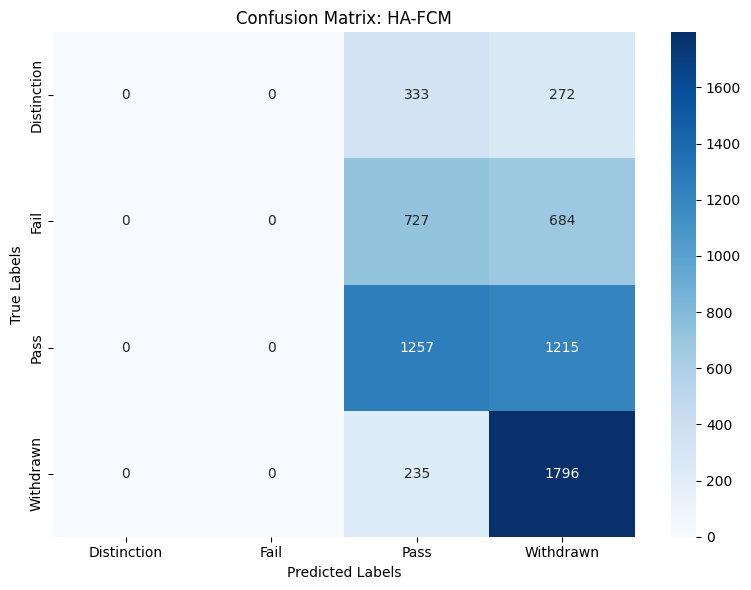

HA-FCM đã chọn: {'m': np.float64(2.1710104724708197), 'ha': True, 'w': np.float64(0.6660308519968928), 'mu': array([0.38506394, 0.35940227, 0.18424595, 0.07128783])} | validation accuracy: 0.5254074784276127


In [3]:
class FuzzyCMeans:
    def __init__(self, n_clusters, m=2., ha=False, w=.5, mu=None):
        self.n_clusters, self.m, self.ha, self.w = n_clusters, m, ha, w
        self.mu = np.asarray(mu if mu is not None else [.25]*4, dtype=float)
        self.mu /= self.mu.sum()  # L, P, M, V
        assert m > 1 and 0 < w < 1 and np.all(self.mu > 0)
        L, P, M, V = self.mu
        self.widths = np.array([V*w, M*w, P*w, L*w,
                               L*(1-w), P*(1-w), M*(1-w), V*(1-w)])
        self.edges = np.cumsum(self.widths)

    def memberships(self, X, centers, radii):
        d = cdist(X, centers)
        if self.ha:
            r = np.clip(1 - d / np.maximum(radii, 1e-12), 0, 1)
            ix = np.clip(np.searchsorted(self.edges, r, side='right'), 0, 7)
            effective = self.widths[ix] * d
        else:
            effective = d
        log_u = -2 / (self.m - 1) * np.log(np.maximum(effective, 1e-12))
        log_u -= log_u.max(axis=1, keepdims=True)
        u = np.exp(log_u)
        u /= u.sum(axis=1, keepdims=True)
        zero = d <= 1e-12
        rows = zero.any(axis=1)
        u[rows] = zero[rows] / zero[rows].sum(axis=1, keepdims=True)
        return u

    def fit(self, X):
        centers = KMeans(self.n_clusters, n_init=10, random_state=SEED).fit(X).cluster_centers_
        for iteration in range(MAX_ITER):
            radii = cdist(X, centers).max(axis=0)
            u = self.memberships(X, centers, radii)
            weights = u ** self.m
            if self.ha:
                weights *= u > self.w
            mass = weights.sum(axis=0)
            new = centers.copy()
            valid = mass > 1e-12
            new[valid] = (weights[:, valid].T @ X) / mass[valid, None]
            movement = np.linalg.norm(new - centers, axis=1).max()
            centers = new
            if movement < TOL:
                break
        self.centers_ = centers
        self.radii_ = cdist(X, centers).max(axis=0)
        self.n_iter_ = iteration + 1
        return self

    def predict(self, X):
        return self.memberships(X, self.centers_, self.radii_).argmax(axis=1)


def cluster_map(model, data, truth):
    cluster = model.predict(data)
    default = np.bincount(truth, minlength=len(labels)).argmax()
    return np.array([np.bincount(truth[cluster == j], minlength=len(labels)).argmax()
                     if np.any(cluster == j) else default for j in labels])


def decode_ha(chromosome):
    return dict(m=chromosome[5], ha=True, w=chromosome[0], mu=chromosome[1:5])

# GA: chọn lọc elitism, lai arithmetic và đột biến; mọi ràng buộc được bảo toàn.
low = np.array([.2, .05, .05, .05, .05, 1.4])
high = np.array([.8, 1., 1., 1., 1., 3.])
population = rng.uniform(low, high, size=(GA_POP, 6))
population[0] = [.5, .25, .25, .25, .25, 2.]
ha_history = []
for generation in range(GA_GEN):
    fitness = []
    for genes in population:
        model = FuzzyCMeans(len(labels), **decode_ha(genes)).fit(A_fit)
        mapping = cluster_map(model, A_fit, y[fit_idx])
        fitness.append(accuracy_score(y[val_idx], mapping[model.predict(A_val)]))
    order = np.argsort(fitness)[::-1]
    elite = population[order[:max(2, GA_POP//3)]]
    ha_history.append(max(fitness))
    if generation == 0 or max(fitness) > best_ha_score:
        best_ha_score = max(fitness)
        best_ha_genes = population[order[0]].copy()
    children = [elite[0].copy()]
    while len(children) < GA_POP:
        a, b = elite[rng.integers(len(elite), size=2)]
        ratio = rng.random(6)
        child = ratio*a + (1-ratio)*b
        child += rng.normal(0, .08, 6) * (high-low) * (rng.random(6) < .3)
        children.append(np.clip(child, low, high))
    population = np.array(children)
    print(f'GA {generation+1}/{GA_GEN}: validation accuracy={best_ha_score:.4f}')

cluster_models = {
    'K-means': KMeans(len(labels), n_init=10, random_state=SEED),
    'FCM': FuzzyCMeans(len(labels)),
    'HA-FCM': FuzzyCMeans(len(labels), **decode_ha(best_ha_genes))
}
for name, model in cluster_models.items():
    model.fit(A_train)
    mapping = cluster_map(model, A_train, y[train_idx])
    evaluate(name, mapping[model.predict(A_test)])
print('HA-FCM đã chọn:', decode_ha(best_ha_genes), '| validation accuracy:', best_ha_score)


## 2. HABR-SIG / HABR-MUL
SQM dùng fm(c-)=theta, mu(L)=alpha, mu(V)=beta=1-alpha. Dấu tương đối: V tăng cường cả L/V; L làm yếu cả L/V. Sinh đệ quy đến độ dài k<=3. SIG đặt mọi term chung một phân hoạch; MUL giữ riêng từng độ dài.

Độ gần (mục 2.3) là (v_i-v_left)/(x-v_left) ở bên phải v_i và (v_right-v_i)/(v_right-x) ở bên trái; ngoài hai term kề thì bằng 0. Hai đầu 0/1 dùng term ảo đối xứng để tránh mẫu số 0 (quy ước biên triển khai). Điều kiện danh nghĩa dùng indicator bằng nhau, không gán thứ tự giả cho region/module/gender.

IFRG: tích độ gần cho AND; confidence=mass_class/mass_all; support=mass_class/N; CF=confidence cao nhất trừ cao thứ hai. Screening bằng confidence*support theo từng lớp. Beam mở rộng các luật tốt đến tối đa 3 điều kiện, không lặp thuộc tính. MOPSO tối ưu hai mục tiêu lỗi validation và tổng số điều kiện: (1) tham số ngữ nghĩa với luật dài 1; (2) mask chọn tập luật. Đây là biến thể có beam để giới hạn số luật ứng viên trên OULAD.


In [4]:
def sqm_partitions(theta, alpha, k):
    beta = 1 - alpha
    # term = (name, v, fm, sign); V positive relative to L/V, L negative.
    current = [('c-', beta*theta, theta, -1),
               ('c+', theta + alpha*(1-theta), 1-theta, 1)]
    partitions = [[('0', 0.), ('W', theta), ('1', 1.)]]
    for level in range(1, k+1):
        terms = [('0', 0.), ('1', 1.)] + [(n, v) for n,v,f,s in current]
        if level == 1:
            terms.append(('W', theta))
        partitions.append(sorted(terms, key=lambda t:t[1]))
        nxt = []
        for name, v, fm, sign in current:
            for hedge, mu, relative in [('L', alpha, -1), ('V', beta, 1)]:
                child_sign = sign * relative
                child_fm = mu * fm
                # omega = (1 + sign(hx)*sign(Vhx)*(beta-alpha))/2 = beta.
                child_v = v + child_sign * (child_fm - beta*child_fm)
                nxt.append((hedge+name, child_v, child_fm, child_sign))
        current = nxt
    return partitions


def ha_closeness(x, knots, i):
    center = knots[i]
    left = knots[i-1] if i > 0 else 2*center-knots[i+1]
    right = knots[i+1] if i+1 < len(knots) else 2*center-knots[i-1]
    eta = np.zeros(len(x), dtype=np.float32)
    a = (x >= left) & (x <= center)
    b = (x > center) & (x <= right)
    eta[a] = (right-center) / np.maximum(right-x[a], 1e-12)
    eta[b] = (center-left) / np.maximum(x[b]-left, 1e-12)
    return eta


class HABR:
    def __init__(self, theta, alpha, k, granularity='MUL'):
        self.theta, self.alpha = np.asarray(theta), np.asarray(alpha)
        self.k = np.asarray(k, dtype=int)
        self.granularity = granularity

    def build_atoms(self, numeric, categorical, fitting=False):
        if fitting:
            self.atoms_ = []
            for j in range(len(num_cols)):
                parts = sqm_partitions(self.theta[j], self.alpha[j], self.k[j])
                if self.granularity == 'SIG':
                    unique = {name:v for part in parts for name,v in part}
                    parts = [sorted(unique.items(), key=lambda t:t[1])]
                else:
                    # k=0: constants only; k>=1: each length is its own partition.
                    parts = parts[1:] if self.k[j] else parts[:1]
                for level, part in enumerate(parts):
                    knots = np.array([v for _,v in part])
                    assert np.all(np.diff(knots) > 0)
                    for i, (term, _) in enumerate(part):
                        self.atoms_.append((j, f'{num_cols[j]} is {term} [partition {level}]', knots, i, None))
            for j, col in enumerate(cat_cols):
                for value in sorted(categorical[col].unique()):
                    self.atoms_.append((len(num_cols)+j, f'{col} = {value}', None, None, value))
        columns = []
        for feature, desc, knots, i, value in self.atoms_:
            if knots is not None:
                columns.append(ha_closeness(numeric[:,feature], knots, i))
            else:
                columns.append((categorical[cat_cols[feature-len(num_cols)]].to_numpy() == value).astype(np.float32))
        return np.column_stack(columns)

    def fit(self, numeric, categorical, truth, max_length=3, per_class=300, beam=30):
        E = self.build_atoms(numeric, categorical, fitting=True)
        self.default_ = np.bincount(truth, minlength=len(labels)).argmax()
        self.rules_ = []
        class_masks = [truth == c for c in labels]

        def score_rule(atoms, grade):
            masses = np.array([grade[mask].sum(dtype=np.float64) for mask in class_masks])
            total = masses.sum()
            if total <= 1e-12:
                return None
            confidence = masses / total
            cls = int(confidence.argmax())
            top = np.sort(confidence)[-2:]
            cf = top[-1]-top[-2]
            if cf <= 1e-12:
                return None
            support = masses[cls] / len(truth)
            return {'atoms': tuple(atoms), 'class': cls, 'CF': cf,
                    'confidence': confidence[cls], 'support': support,
                    'screen': confidence[cls]*support}

        def screen(rules, count):
            return [r for c in labels for r in sorted(
                (r for r in rules if r['class'] == c),
                key=lambda r:(-r['screen'], r['atoms']))[:count]]

        single = [score_rule((a,), E[:,a]) for a in range(E.shape[1])]
        single = [r for r in single if r is not None]
        all_rules = list(single)
        frontier = screen(single, beam)
        # Beam pool contains the strongest atomic conditions from every class.
        pool = sorted({r['atoms'][0] for r in screen(single, beam)})
        seen = {r['atoms'] for r in single}
        for length in range(2, max_length+1):
            extension = []
            for rule in frontier:
                old = rule['atoms']
                features = {self.atoms_[a][0] for a in old}
                base = np.prod(E[:,old], axis=1)
                for a in pool:
                    if self.atoms_[a][0] in features:
                        continue
                    atoms = tuple(sorted((*old,a)))
                    if atoms in seen:
                        continue
                    seen.add(atoms)
                    scored = score_rule(atoms, base*E[:,a])
                    if scored is not None:
                        extension.append(scored)
            all_rules.extend(extension)
            frontier = screen(extension, beam)
        self.rules_ = screen(all_rules, per_class)
        if not self.rules_:
            raise ValueError('Không sinh được luật có CF dương.')
        self.active_ = np.ones(len(self.rules_), dtype=bool)
        return self

    def rule_scores(self, numeric, categorical):
        E = self.build_atoms(numeric, categorical)
        return np.column_stack([np.prod(E[:,r['atoms']], axis=1)*r['CF'] for r in self.rules_])

    def predict_scores(self, scores, active=None):
        active = self.active_ if active is None else np.asarray(active, dtype=bool)
        if not active.any():
            return np.full(len(scores), self.default_, dtype=int)
        ix = np.flatnonzero(active)
        selected = scores[:,ix]
        best = selected.argmax(axis=1)
        pred = np.array([self.rules_[j]['class'] for j in ix])[best]
        pred[selected.max(axis=1) <= 0] = self.default_
        return pred

    def predict(self, numeric, categorical):
        return self.predict_scores(self.rule_scores(numeric, categorical))

    def rule_table(self):
        return pd.DataFrame([{'IF': ' AND '.join(self.atoms_[a][1] for a in r['atoms']),
                              'THEN': target_names[r['class']], 'CF': r['CF'],
                              'confidence': r['confidence'], 'support': r['support']}
                             for r,active in zip(self.rules_,self.active_) if active])



Tối ưu HABR-SIG


Validation accuracy: 0.8473633748801535 | Selected rules: 574 | Conditions: 1593



Model: HABR-SIG
              precision    recall  f1-score   support

 Distinction       0.76      0.27      0.40       605
        Fail       0.94      0.73      0.82      1411
        Pass       0.74      0.96      0.84      2472
   Withdrawn       1.00      0.99      1.00      2031

    accuracy                           0.86      6519
   macro avg       0.86      0.74      0.76      6519
weighted avg       0.87      0.86      0.84      6519



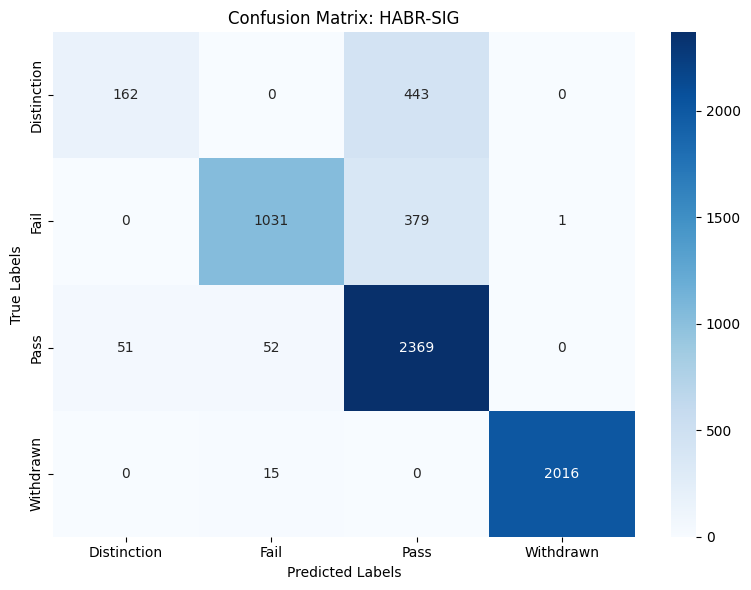

,IF,THEN,CF,confidence,support
571,has_unregistered is 1 [partition 0] AND assessment...,Withdrawn,1.000000,1.000000,0.108383
557,has_unregistered is 1 [partition 0] AND tool_sum_c...,Withdrawn,1.000000,1.000000,0.114420
556,has_unregistered is 1 [partition 0] AND code_prese...,Withdrawn,1.000000,1.000000,0.114482
205,has_unregistered is Vc- [partition 0] AND average_...,Fail,1.000000,1.000000,0.016171
191,has_unregistered is 0 [partition 0] AND average_sc...,Fail,1.000000,1.000000,0.022791
517,num_of_prev_attempts is 0 [partition 0] AND has_un...,Withdrawn,0.998527,0.999263,0.131584
508,has_unregistered is 1 [partition 0] AND highest_ed...,Withdrawn,0.998356,0.999178,0.139833
512,has_unregistered is 1 [partition 0] AND content_re...,Withdrawn,0.998351,0.999176,0.137550
511,has_unregistered is 1 [partition 0] AND navigation...,Withdrawn,0.998347,0.999173,0.137879
551,num_of_prev_attempts is 0 [partition 0] AND has_un...,Withdrawn,0.998264,0.999132,0.115636



Tối ưu HABR-MUL


Validation accuracy: 0.8502396931927133 | Selected rules: 568 | Conditions: 1582



Model: HABR-MUL
              precision    recall  f1-score   support

 Distinction       0.79      0.28      0.42       605
        Fail       0.88      0.78      0.83      1411
        Pass       0.76      0.93      0.83      2472
   Withdrawn       1.00      0.99      1.00      2031

    accuracy                           0.86      6519
   macro avg       0.86      0.75      0.77      6519
weighted avg       0.86      0.86      0.84      6519



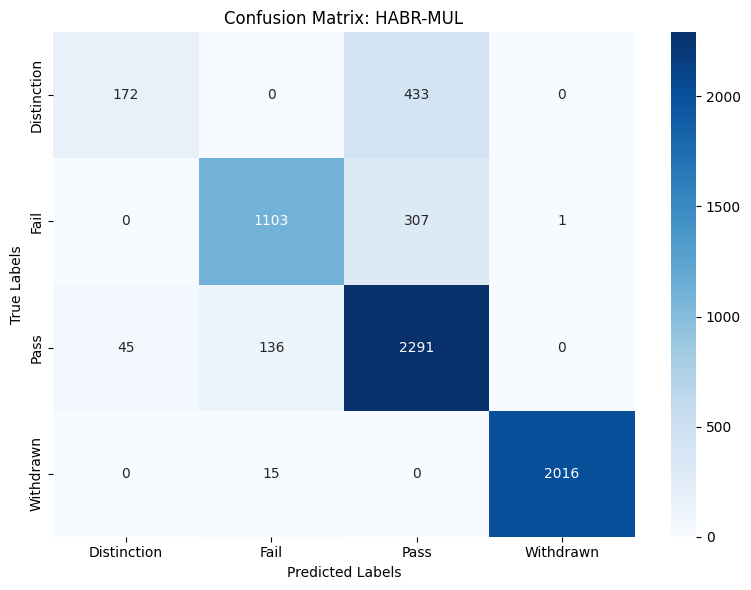

,IF,THEN,CF,confidence,support
555,num_of_prev_attempts is 0 [partition 0] AND has_un...,Withdrawn,0.998093,0.999046,0.218723
528,num_of_prev_attempts is 0 [partition 0] AND has_un...,Withdrawn,0.998082,0.999041,0.229801
465,num_of_prev_attempts is 0 [partition 0] AND has_un...,Withdrawn,0.998082,0.999041,0.278637
466,num_of_prev_attempts is 0 [partition 0] AND has_un...,Withdrawn,0.998081,0.999041,0.275622
467,num_of_prev_attempts is 0 [partition 0] AND has_un...,Withdrawn,0.998077,0.999038,0.275008
468,num_of_prev_attempts is 0 [partition 0] AND has_un...,Withdrawn,0.998053,0.999026,0.272826
442,num_of_prev_attempts is 0 [partition 0] AND has_un...,Withdrawn,0.998053,0.999026,0.290944
565,num_of_prev_attempts is 0 [partition 0] AND date_r...,Withdrawn,0.998035,0.999018,0.227538
490,num_of_prev_attempts is 0 [partition 0] AND has_un...,Withdrawn,0.998031,0.999015,0.260367
532,has_unregistered is 1 [partition 0] AND interactio...,Withdrawn,0.998028,0.999014,0.227129


In [5]:
def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)


def mopso(objective, dimension, generations, initial=None):
    local_rng = np.random.default_rng(SEED)
    position = local_rng.random((PSO_POP, dimension))
    if initial is not None:
        position[0] = initial
    velocity = np.zeros_like(position)
    pbest = position.copy()
    pvalue = np.array([objective(p) for p in position])
    archive = []
    history = []

    def update_archive(points, values):
        nonlocal archive
        candidates = archive + [(p.copy(), v.copy()) for p,v in zip(points, values)]
        unique = {}
        for p,v in candidates:
            key = tuple(v)
            unique.setdefault(key, (p,v))
        candidates = list(unique.values())
        archive = [(p,v) for p,v in candidates
                   if not any(dominates(w,v) for q,w in candidates)]
        # Bảo toàn hai cực accuracy/complexity, lấy mẫu nếu archive quá lớn.
        archive.sort(key=lambda item:tuple(item[1]))
        if len(archive) > 40:
            indices = np.linspace(0, len(archive)-1, 40).astype(int)
            archive = [archive[i] for i in indices]

    update_archive(position, pvalue)
    for gen in range(generations):
        leaders = np.array([archive[local_rng.integers(len(archive))][0] for _ in position])
        velocity = (.4*velocity + .2*local_rng.random(position.shape)*(pbest-position)
                    + .2*local_rng.random(position.shape)*(leaders-position))
        position = np.clip(position+velocity, 0, 1)
        values = np.array([objective(p) for p in position])
        for i in range(PSO_POP):
            if dominates(values[i], pvalue[i]) or (
                not dominates(pvalue[i], values[i]) and local_rng.random() < .5):
                pbest[i], pvalue[i] = position[i].copy(), values[i].copy()
        update_archive(position, values)
        best = min(archive, key=lambda item:tuple(item[1]))
        history.append(best[1].copy())
    return min(archive, key=lambda item:tuple(item[1]))[0], np.array(history), archive


def semantic_decode(p):
    n = len(num_cols)
    return .2+.6*p[:n], .2+.6*p[n:2*n], np.rint(3*p[2*n:]).astype(int)


def cat_data(indices):
    return X.iloc[indices][cat_cols].fillna('__MISSING__').astype(str).reset_index(drop=True)

cat_fit, cat_val, cat_train, cat_test = map(cat_data, [fit_idx, val_idx, train_idx, test_idx])
N_fit, N_val = A_fit[:,:len(num_cols)], A_val[:,:len(num_cols)]
N_train, N_test = A_train[:,:len(num_cols)], A_test[:,:len(num_cols)]


def recalibrate_selected(model, numeric, categorical, truth):
    # Giữ antecedent đã chọn; refit confidence/support/CF trên toàn bộ 80% train.
    E = model.build_atoms(numeric, categorical)
    selected = [r for r,a in zip(model.rules_,model.active_) if a]
    updated = []
    for r in selected:
        grade = np.prod(E[:,r['atoms']], axis=1)
        masses = np.array([grade[truth == c].sum(dtype=np.float64) for c in labels])
        if masses.sum() <= 1e-12:
            continue
        confidence = masses/masses.sum()
        cls = int(confidence.argmax())
        cf = np.sort(confidence)[-1]-np.sort(confidence)[-2]
        if cf > 1e-12:
            updated.append({**r, 'class':cls, 'CF':cf, 'confidence':confidence[cls],
                            'support':masses[cls]/len(truth)})
    model.rules_ = updated
    model.active_ = np.ones(len(updated), dtype=bool)
    model.default_ = np.bincount(truth, minlength=len(labels)).argmax()
    if not updated:
        raise ValueError('Không còn luật sau refit.')
    return model

habr_models, optimization_history = {}, {}
for granularity in ['SIG', 'MUL']:
    print('\nTối ưu HABR-' + granularity)
    cache = {}
    initial = np.r_[np.full(2*len(num_cols), .5), np.full(len(num_cols), 2/3)]
    def semantic_objective(p):
        theta, alpha, k = semantic_decode(p)
        key = tuple(np.round(np.r_[theta,alpha,k], 6))
        if key not in cache:
            model = HABR(theta,alpha,k,granularity).fit(
                N_fit,cat_fit,y[fit_idx],max_length=1,
                per_class=max(1, int(np.ceil(X.shape[1]/len(labels)))), beam=BEAM_PER_CLASS)
            pred = model.predict(N_val,cat_val)
            cache[key] = np.array([1-accuracy_score(y[val_idx],pred), len(model.rules_)], dtype=float)
        return cache[key]
    best_semantic, sem_history, _ = mopso(semantic_objective, len(initial), SEM_GEN, initial)
    theta, alpha, k = semantic_decode(best_semantic)
    candidate = HABR(theta,alpha,k,granularity).fit(
        N_fit,cat_fit,y[fit_idx],MAX_RULE_LENGTH,RULES_PER_CLASS,BEAM_PER_CLASS)
    scores = candidate.rule_scores(N_val,cat_val)
    lengths = np.array([len(r['atoms']) for r in candidate.rules_])
    def rule_objective(p):
        mask = p >= .5
        if not mask.any():
            return np.array([1., 0.])
        pred = candidate.predict_scores(scores,mask)
        return np.array([1-accuracy_score(y[val_idx],pred), lengths[mask].sum()], dtype=float)
    best_mask, rule_history, _ = mopso(rule_objective,len(candidate.rules_),RULE_GEN,
                                      np.ones(len(candidate.rules_)))
    candidate.active_ = best_mask >= .5
    if not candidate.active_.any():
        raise ValueError('MOPSO chọn tập luật rỗng.')
    print('Validation accuracy:', 1-rule_objective(best_mask)[0],
          '| Selected rules:', int(candidate.active_.sum()),
          '| Conditions:', int(lengths[candidate.active_].sum()))
    final_model = recalibrate_selected(candidate,N_train,cat_train,y[train_idx])
    name = 'HABR-' + granularity
    habr_models[name] = final_model
    optimization_history[name] = (sem_history,rule_history)
    evaluate(name,final_model.predict(N_test,cat_test))
    display(final_model.rule_table().sort_values('CF',ascending=False).head(10))


## 3. So sánh kết quả
Mọi mô hình được đánh giá trên cùng 20% test, giữ nguyên bốn lớp trong final_result. Macro F1 giúp xem hiệu quả giữa các lớp khi phân bố mất cân bằng; không dùng bảng test này để tiếp tục chỉnh tham số.


In [6]:
comparison = pd.DataFrame(results).set_index('Model')
display(comparison.round(4))
assert set(predictions) == {'K-means','FCM','HA-FCM','HABR-SIG','HABR-MUL'}
assert all(len(p) == len(test_idx) for p in predictions.values())
assert all(np.isin(p,labels).all() for p in predictions.values())
print('Hoàn tất đánh giá 5 mô hình trên cùng tập test.')


,Accuracy,Macro F1,Weighted F1
Model,,,
K-means,0.3792,0.1375,0.2085
FCM,0.3795,0.1380,0.2092
HA-FCM,0.4683,0.2748,0.3763
HABR-SIG,0.8557,0.7627,0.8422
HABR-MUL,0.8563,0.7687,0.8441


Hoàn tất đánh giá 5 mô hình trên cùng tập test.


In [7]:
# Kiểm tra công thức: SQM, độ gần rational, khoảng HA và membership.
p = sqm_partitions(.5, .5, 2)
assert np.allclose([v for name,v in p[1] if name in ('c-','c+')], [.25,.75])
values = dict(p[2])
assert np.allclose([values[t] for t in ['Vc-','Lc-','Lc+','Vc+']], [.125,.375,.625,.875])
eta = ha_closeness(np.array([.2,.25,.3,.8]), np.array([0.,.25,.5]), 1)
assert np.allclose(eta, [5/6,1.,5/6,0.])
centers = np.array([[0.,0.],[2.,0.]])
sample = np.array([[0.,0.],[1.,0.],[2.,0.]])
radii = np.array([2.,2.])
fcm = FuzzyCMeans(2)
ha = FuzzyCMeans(2,ha=True,w=.5,mu=[.25]*4)
u = fcm.memberships(sample,centers,radii)
assert np.allclose(ha.widths.sum(),1.)
assert np.allclose(u.sum(axis=1),1.)
assert np.allclose(u, [[1.,0.],[.5,.5],[0.,1.]])
# Với độ dài khoảng bằng nhau, cập nhật membership HA trùng FCM.
assert np.allclose(u,ha.memberships(sample,centers,radii))
assert np.allclose(ha.memberships(sample[:1],centers,radii),
                   ha.memberships(sample,centers,radii)[:1])
print('Kiểm tra công thức SQM, độ gần HA và membership: PASS')


Kiểm tra công thức SQM, độ gần HA và membership: PASS
